# Parallel Python

This course is adapted from the post-graduate [Parallel Python Training Course](https://milliams.com/courses/parallel_python/Functional%20programming.html), created at the [University of Bristol](https://www.bristol.ac.uk), created by Christoper Woods and revised by Matt Williams.

### Table of Contents
1. [Memory Management in Python](#memory-management-in-python)

2. [Functional Programming](#functional-programming)
    * [Functions as Arguments](#functions-as-arguments)
    
3. [Local Multicore Processing](#local-multicore-processing)
    * [Process Pooling](#process-pooling)
        - [Asynchronous Functions](#asynchronous-functions)
        - [Futures](#futures)
        - [Asynchronous Mapping](#asynchronous-mapping)
        - [Chunking](#chunking)
    * [Thread Pooling](#thread-pooling)
4. [Multi-node Parallel Programming](#multi-node-parallel-programming)

## Memory Management in Python

Memory allocation can be defined as allocating a block of space in the computer memory to a program. In Python memory allocation and deallocation method is automatic as the Python developers created an automatic garbage collector.

**Garbage collection** is a process in which the interpreter frees up memory when not in use to make it available for other objects. For example, if an object which is stored in memory has no reference pointing to it, it will be treated as garbage and deleted to free up space. 

---

There are two parts to memory:

#### Stack

Stores function/method calls and **references** (*i.e.,* variable names) to objects (ints, lists, dictionaries, dataframes, ...) in contiguous blocks of memory.

The stack follows the LIFO (Last in, First out) principle, meaning the last item added to the stack will be the first to be deleted once the function/method call has completed. The size of the memory to be allocated is known to the complier. Whenever a function/method is called, its local variables are allocated on the stack. When the function has returned, any local memory assignments stored on the stack are deleted to free up space. The call stack will then move to the task that is directly next to the previous item that was just deleted.

>This explains why variables defined locally within a function cannot be referenced outside of the function scope. As soon as the function returns, the reference to that object is deleted from the stack. If no other references point to that object on the heap, Python's garbage collector deletes the value stored on the heap to free up memory.

#### Heap

Objects (instances of a class) such as ints, bools, lists, functions, dictionaries, pandas dataframes, ... (in Python, almost everything) are stored on the heap. 

Points to note:

* Global variables (such as num = 10) will be entirely stored on the heap. There is some nuance here. The value 10 will be allocated to heap memory and the reference/variable name (num) will be contained within a global dictionary object (`globals()`) which is **also** stored on the heap.

* Python employs **integer caching**. This is a special optimization technique where small integer values (typically -5 to 256) are pre-stored and reused, rather than getting Python to create new objects to represent the same integer value. This prevents wasting space in memory.

In [1]:
print(globals())

{'__name__': '__main__', '__doc__': 'Automatically created module for IPython interactive environment', '__package__': None, '__loader__': None, '__spec__': None, '__builtin__': <module 'builtins' (built-in)>, '__builtins__': <module 'builtins' (built-in)>, '_ih': ['', 'print(globals())'], '_oh': {}, '_dh': [WindowsPath('c:/Users/benke/Desktop/Dataquest/Python_projects/parallel-python')], 'In': ['', 'print(globals())'], 'Out': {}, 'get_ipython': <bound method InteractiveShell.get_ipython of <ipykernel.zmqshell.ZMQInteractiveShell object at 0x0000017FB608B4D0>>, 'exit': <IPython.core.autocall.ZMQExitAutocall object at 0x0000017FB612CD70>, 'quit': <IPython.core.autocall.ZMQExitAutocall object at 0x0000017FB612CD70>, 'open': <function open at 0x0000017FB3CD6660>, '_': '', '__': '', '___': '', '__vsc_ipynb_file__': 'c:\\Users\\benke\\Desktop\\Dataquest\\Python_projects\\parallel-python\\parallel-python.ipynb', '_i': '', '_ii': '', '_iii': '', '_i1': 'print(globals())'}


In [2]:
c = 10
d = 10

e = 1000
f = 1000

print(c is d) # integer caching. c and d point to the same object in memory
print(c == d)
print("-----")
print(e is f) # e and f point to two separate objects which are created in memory. 1000 falls outside of the typical integer caching range
print(e == f)

True
True
-----
False
True


## Functional Programming

Perhaps the easiest way to write efficient parallel programs is through use of **functional programming**. The principle behind this style of programming is to define and run many functions in parallel on large quantities of data. After designing the functions, they are connected together with any required dependencies to create a "team" that can be distributed across multiple cores of a processor (or nodes of a cluster if working with many computers).

---

In functional programming, we treat functions as variables.

In [3]:
def add(x: int|float, y: int|float) -> int|float:
  """A simple function which returns the sum of two arguments.
  
  Args:
    x (int or float): The first number
    y (int or float): The second number.
  
  Returns:
    *int or float*:
    The sum of x and y.
  """
  return x + y

In [4]:
add(7, 11)

18

We are comfortable with the idea that variable names refer to a piece of data stored on the heap, so there is nothing stopping us from assigning a reference to a function in the same way as we assign a reference to a piece of data:

In [5]:
a = add
a(7, 11)

18

We can extract the dunder methods associated with the function class from the reference:

In [6]:
a.__name__, a.__doc__

('add',
 'A simple function which returns the sum of two arguments.\n\nArgs:\n  x (int or float): The first number\n  y (int or float): The second number.\n\nReturns:\n  *int or float*:\n  The sum of x and y.\n')

### Functions as Arguments

In [7]:
def call_function(func, x, y):
   """
    A simple function that calls the function 'func' with  
    arguments 'arg1' and 'arg2', returning the result
   """
   print(f"Calling function {func.__name__} with arguments {x} and {y}")
   return func(x, y)

call_function(add, 7, 11)

Calling function add with arguments 7 and 11


18

#### Map Function

Python contains a built-in `map()` function which is able to apply a function across iterable arguments. 

In [8]:
lst1 = [1, 4, 7, 9, 13]
lst2 = [2, 3, 9, 10, 17, 18] # the sixth element has no counterpart in lst1, so is ignored by the map function

result = list(map(add, lst1, lst2))
result

[3, 7, 16, 19, 30]

#### Reduce Function

Reduction is a counterpart to mapping. In many cases, we want to reduce N elements down into a single element. The standard `functools` library contains a `reduce()` function to handle this.

In [9]:
from functools import reduce

print(reduce(add, result))

print(reduce(lambda x,y: x+y, result))

75
75


The `reduce()` function computes the following: $((((3+7)+16)+19)+30)$

## Local Multicore Processing

Python offers many libraries to assist in parallising scripts across the cores of a single computer. The traditional option is the `multiprocessing` library, but since Python 3.2, the `concurrent.futures` module is more commonly used. This module is built off of the `multiprocessing` library.

In [10]:
import os

os.cpu_count()

24

This PC has 24 available cores, meaning up to 24 tasks can be executed in parallel.

`concurrent.futures` provides a number of ways to achieve parallelism. One of the simplest utilizes `process pool execution` by running multiple copies of a script in parallel. Typically, each core will execute one copy of a script.

One of these copies is referred to as the `master copy` and is the one which oversees all other copies (known as `worker copies`). The scripts must be executed via a terminal using `if __name__ == "__main__"` to protect the master copy.

### Process Pooling

One of the core `concurrent.futures` classes is the `ProcessPoolsExecutor`. This provides a pool of workers that can be used to parallelize a map. 

To create a pool, a context manager is used. An instance of the `ProcessPoolsExecutor` class can be instantiated and methods can be called on it (such as map) to apply a function to iterables.

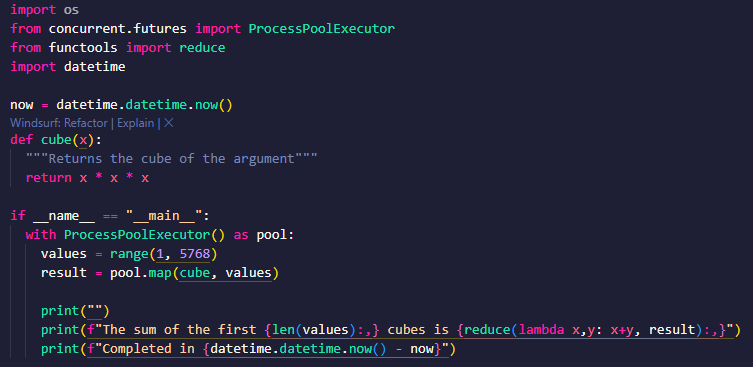

Running the script (python version 3.13.5):

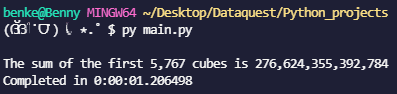

The map function is divided between all workers in the pool (this can be set using the max_workers argument in the pool instance). We can confirm this by using an `os.getpid` call (this returns the process ID of the worker that executes each calculation).


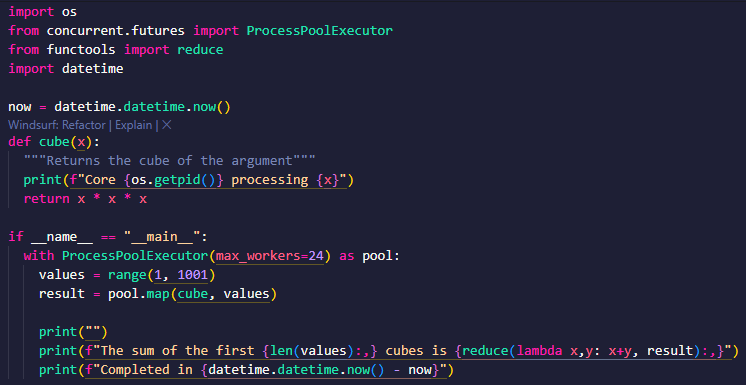

Result:

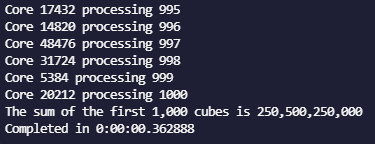

### Pros and Cons of Process Pooling

+ True parallelism is achieved since each process runs simultaneously. This is **great** for CPU intensive tasks (*e.g.,* hard-core maths calculations, image processing, data crunching - ML data preprocessing).

---

- Data must be pickled in order to be sent between processes (each process uses separate memory). One consequence of this: the ProcessPoolExecutor does not support lambda functions. This is because functions need to be **pickled** (aka serialized) in order to be sent to another process. Lambda functions **cannot be pickled**. This restricts us from using top-level defined functions when using the ProcessPoolExecutor - functions must be defined explicitly above the if \_\_name\_\_ = "\_\_main\_\_" block.

- More memory intensive

- Can be slow to start


### Asynchronous Functions

As we saw above, the `ProcessPoolExecutor` enables mapping of a single function to a set of data across multiple cores. 

**What if we want to apply many different functions?** 

The solution here is to instruct individual workers (cores) to run different functions by submitting functions to each worker.

The `ProcessPoolExecutor` class comes with a method `.submit()` to instruct one process in the worker pool to run a specified function.

For example:

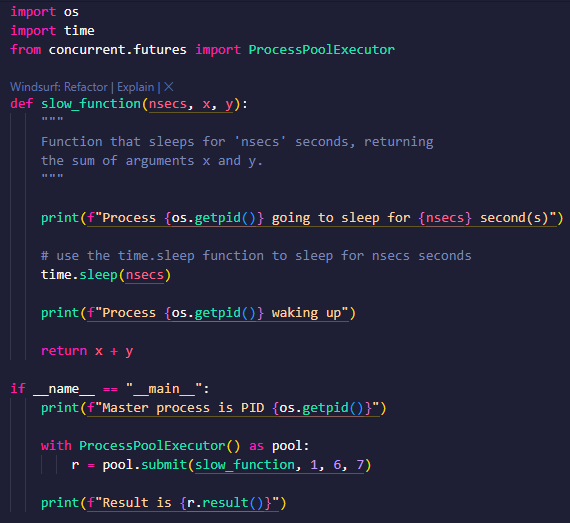

The key line is `r = pool.submit(slow_function, 5)`. This requests one of the workers in the pool to execute the slow_function with the provided argument. The value returned by pool.submit is a special object, hence the need to use the `.result()` method to retrieve the result:

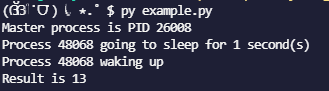
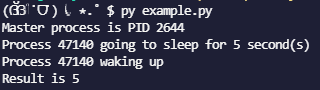

The reason for the `.result()` method is that it enables us to submit multiple functions in parallel and then request the results once each has been processed:

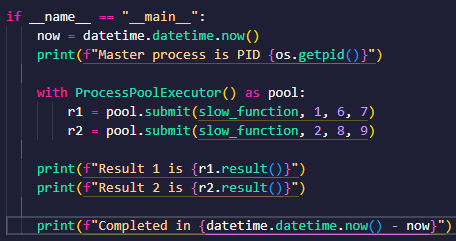

Result: 

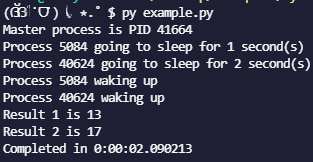

The key thing to notice is that both functions begin executing nearly at the same time. Each is being handled by a different worker, so the first task does not need to complete before the next can begin. The combined execution time is just over 2 seconds when the total wait time to execute both functions is at least 3 seconds. This is the power of running functions in parallel rather than sequentially.

### Futures

When running functions asynchronously as demonstrated above, it is important to appreciate that the return value of each function is not available immediately. Instead, the `.submit()` method will return a *placeholder* for the return value known as a **future** (*i.e.,* it will be available in the future).

Futures are very common objects in parallel programming, providing common functionality:

* Block (wait) until the result is available. Using `concurrent.futures` this is done implicitly via the `.result()` method. This essentially means the `.result()` method will not be called prematurely before the result is available. There is also an implicit wait incorporated into context managers (`with` block) when they close - ensuring all processes have finished executing.

* Test whether a result is available. This can be achieved using the `.done()` method. When this returns True, the result is available via the `.result()` method.

* Test whether or not the function successfully returned a result. This is achieved using the `.exception()` method, returning None if the function executed successfully, or raising an exception if not.

To demonstrate some of this functionality:

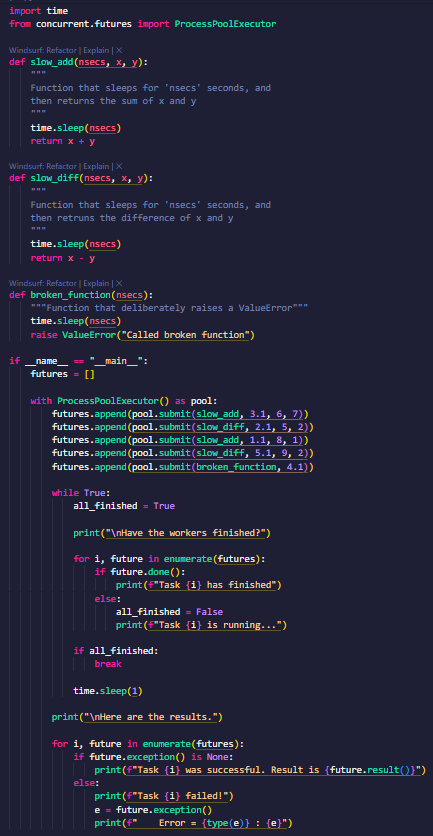

Results:

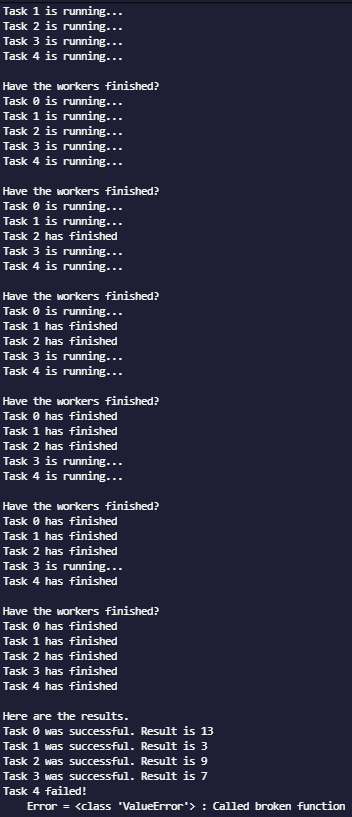

### Asynchronous Mapping

Giving functions one by one is not very efficient. It would be better to combine mapping with asynchronous functions, giving different mapping tasks simultaneously to the pool of workers.

An example:

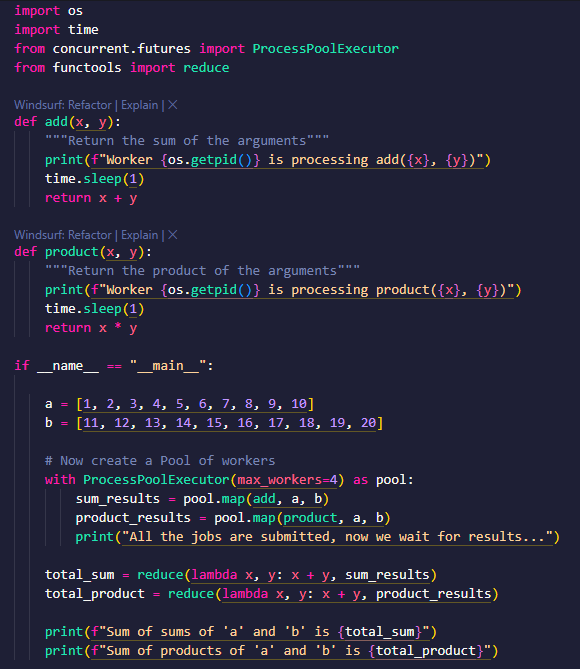

Results:

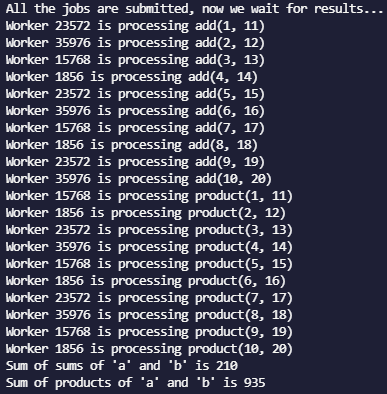
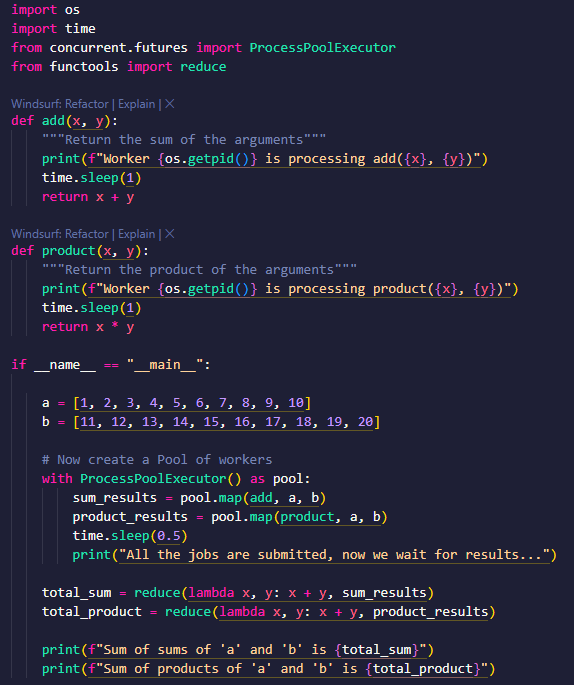
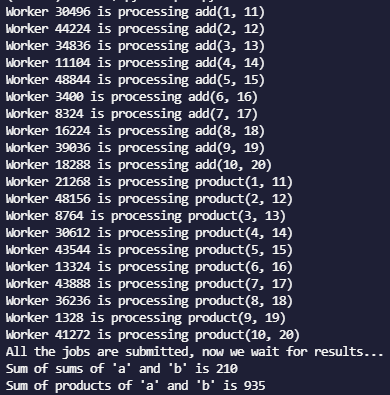

This script provides two functions (`add` and `product`) which are mapped using `ProcessPoolsExecutor.map`. Mapping is performed asynchronously, in the same manner as `.submit()`. Map however does not return a `Future` object, instead, the results are automatically waited-for as the results are looped through.

### Chunking

In the above example, work is assigned to the four workers one-by-one. For instance, the first worker process was given add(1, 11), the second add(2, 12), third add(3, 13) and fourth add(4, 14). The first worker to finish is only then given their next task: add(5, 15), *etc.* 

This can be very inefficient for quick tasks since the time needed by a worker process to stop and get new work can be longer than it takes to actually complete the task. To solve this issue, **chunking** can be used. This controls how many items of work are handed out to each worker at a time. 

This is implemented simply by passing the `chunksize` argument to the pool.map method.

Example:

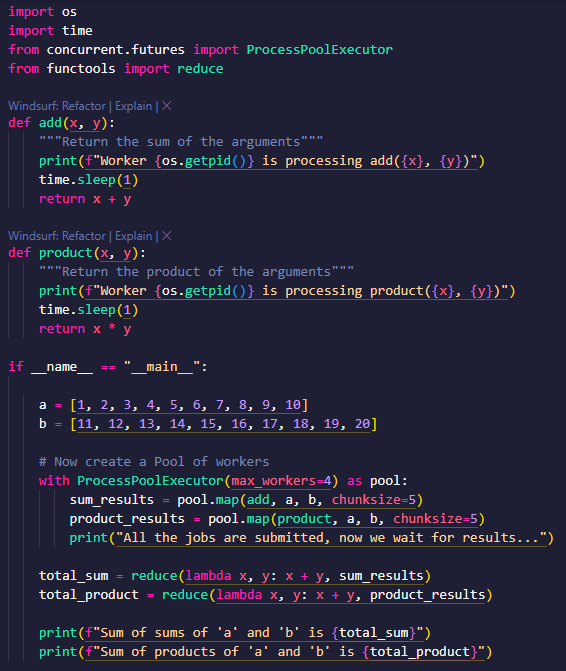

Results:

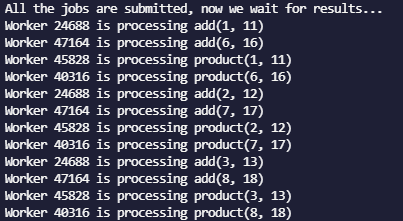

*etc.*

Here, the first worker is assigned the first five items of work: add(1, 11) to add(5, 15). It begins by executing add(1, 11) and then moves onto its next task as soon as it finishes the previous. The same pattern applies to the other three workers. The second receives tasks: add(6, 16) to add(10, 20), and so-on.

It is always a good idea to experiment with `chunksize` to optimize runtime performance.

---

### Thread Pooling

Thread pooling is a counterpart to process pooling that is best applied in different contexts. The `concurrent.futures` module contains the `ThreadPoolExecutor` for multi-threading.

* Multiple threads are created within the **same** process. A thread is essentially a lightweight execution unit within a single core - sharing the same memory.

* Each thread has its own stack. This is not true parallelism since the Python interpreter (CPython) makes use of something known as the GIL (Global Interpreter Lock), only allowing one thread to execute Python bytecode at a time per process.

The GIL exists to make memory management safe and simple. Without the GIL, multiple threads may update the reference counts simultaneously (which is how Garbage collection is handled). This could lead to memory corruption. 

### Pros and Cons of Thread Pooling

+ Fast to create and switch between threads, making this technique **great** for I/O-bound tasks (Input-Output). 

+ No pickling is required. One consequence: lambda functions are supported.

Essentially, multi-threading is useful for any tasks that require waiting such as performing multiple API calls at once, reading/writing to many files (file I/O) and querying multiple databases. Why does this speed up wait times? 

The key is that the GIL is only in effect during bytecode execution - it is released during I/O tasks, meaning that threads are able to begin running as soon as they are ready (e.g., performing a HTTP request) whilst others may be waiting for I/O.

---

- Limited by the GIL, preventing true parallelism. This makes it a poor choice for CPU-intensive tasks.

To demonstrate an application of thread pooling, we can download the text files of three books from three separate URLs:

* War and Peace (Leo Tolstoy)

* Moby Dick (Herman Melville)

* Medical Essays (Oliver Wendell Holmes)

Without multi-threading:

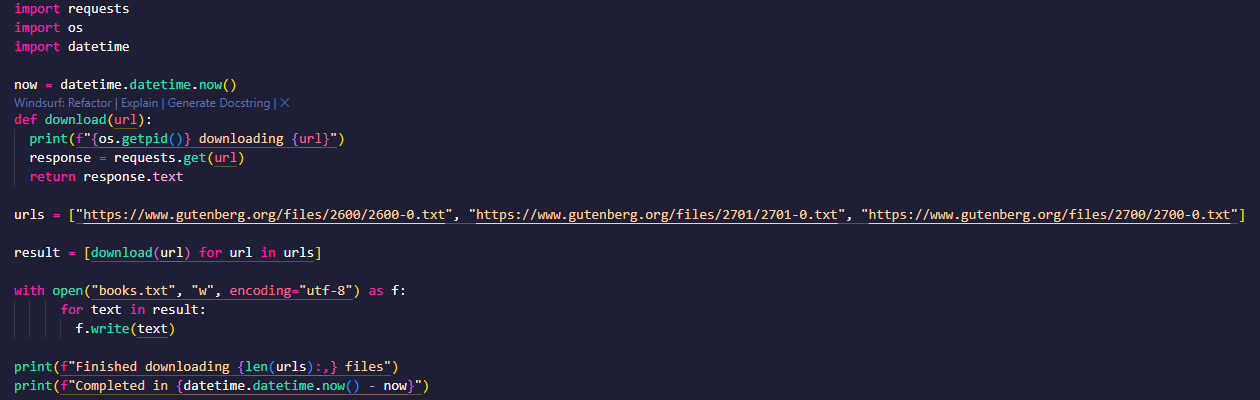

Results:

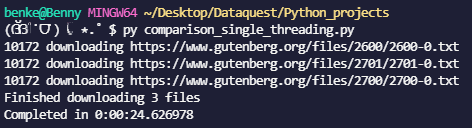

Looking at the script during runtime, each URL was sent a request one-by-one - only one thread is available, so only once the previous task finishes can the next start. This took a total of 24.6 seconds.

---

**With** multi-threading: 

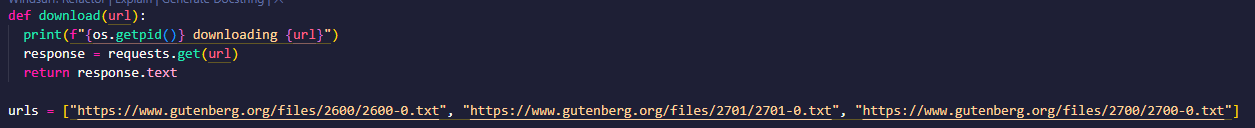

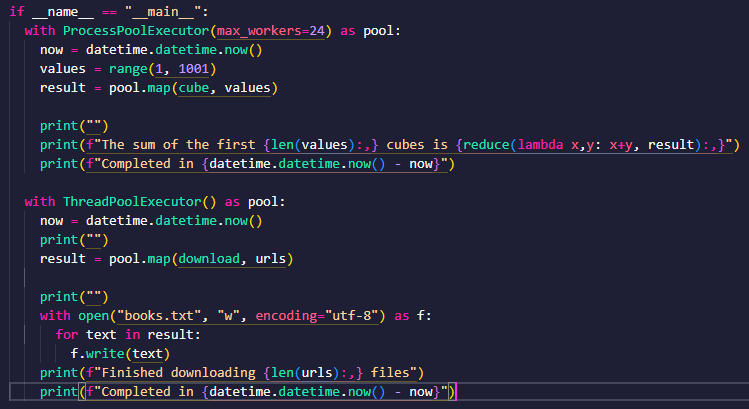

Results:

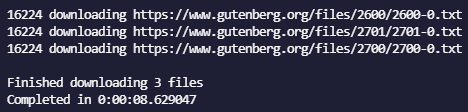

All three URLs were sent a request simultaneously, with each URL being handled by a separate thread, significantly reducing the time taken to retrieve all of the data (taking only 8.6 seconds).

## Multi-node Parallel Programming

Python comes with in-built support for parallelizing scripts locally through the `multiprocessing` and `concurrent.futures` module as we have seen. When it comes to parallelizing scripts over nodes of a cluster (*i.e.,* cloud computing, HPC (high-performance computing) and distributed compute clusters), third party libraries including `MPI4Py`, `Dask`, `IPython Parallel` and `Parallel Python` can be utilized.

Here, we will focus on [MPI4Py](https://mpi4py.readthedocs.io/en/stable/install.html) which supports parallelizing scripts across clouds, HPC clusters and distributed compute clusters. 

MPI4Py provides a low-level interface for creating full MPI-style programs, but it also has a much simpler API which allows scripts to be written in much the same way as they are for local multi-processing.

An example script:

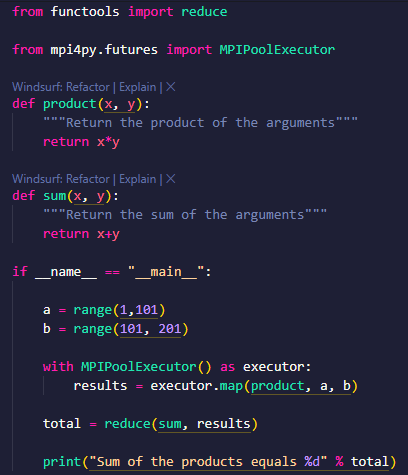



The only difference `ProcessPoolExecutor` is replaced with the `MPIPoolExecutor` class from the `mpi4py.futures` module.

The way in which the script will be run depends on the MPI version. This goes beyond the scope of this document as it is best managed by the HPC team at a particular organization. 

In brief, a script is run through a standard MPI tool called `mpiexec` which establishes communication with the potentially many computers taking part in the calculation. The Python script will be started on each computer in the cluster.

Typically the command will usually look something like:



which will start a master process which manages the master worker and 16 other workers (in the above example) to run the map over. The number of workers created will depend on the cluster that you are running on - this is organization dependent.